# Actividad final
## Microcredencial en Ciencia de Datos — Universidad de Oviedo
### Análisis Exploratorio, Limpieza y Preparación de Datos

**Objetivo**: Ejecutar el pipeline completo de análisis y preparación de datos sobre un caso real, documentando cada decisión.  
**Dataset**: HR_Data_Analysis_Prediction (`aug_train.csv`) — 19158 predicciones. Un análisis breve de las causas que pueden llevar a que los empleados busquen abandonar la empresa tras completar la formación.   
**Variable objetivo**: `target` — siendo 1 que busque abandonar y 0 que no.  

---

## Índice
0. **Carga de librerías**.
1. **Estudio descriptivo de las variables**
2. **Estudio de las relaciones entre variables**
3. **Análisis exploratorio bivariado**
4. **Tratamiento de outliers**
5. **Imputación de valores perdidos**
6. **Tratamiento de variables categóricas**
---

> **Cómo leer este notebook**: Cada sección comienza con una explicación en texto de **qué vamos a hacer** y **por qué**. Después viene el código. Al final de cada sección hay una celda de conclusiones. No ejecutes el código antes de leer el texto — el análisis es tan importante como el resultado.

---
## 0. Carga de librerías

Importamos todas las librerías que necesitamos. Usamos `warnings.filterwarnings('ignore')` para no contaminar la salida del notebook con avisos de deprecación — en producción lo quitaríamos.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, OrdinalEncoder, OneHotEncoder

warnings.filterwarnings('ignore')

---
## 1. Estudio descriptivo de las variables

### ¿Qué hacemos aquí?
Antes de hacer nada con los datos, necesitamos responder cuatro preguntas básicas:
1. **¿Cuántas filas y columnas tiene el dataset?** — escala del problema
2. **¿Qué tipo tiene cada variable?** — determina qué operaciones son aplicables
3. **¿Hay valores perdidos?** — dónde están y cuántos
4. **¿Qué rango de valores tiene cada variable?** — detectar si los números tienen sentido

### ¿Por qué es importante?
Un error muy común es empezar a transformar datos sin haberlos entendido. El resultado es transformaciones incorrectas que introducen errores silenciosos — el código corre sin error pero los datos están mal.

### 1.1 Visión general

In [23]:
data = pd.read_csv("data/aug_train.csv")
print(f'Dimensiones: {data.shape}')
print(f'Columnas: {list(data.columns)}')
data.head()

Dimensiones: (19158, 14)
Columnas: ['enrollee_id', 'city', 'city_development_index', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job', 'training_hours', 'target']


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


In [24]:
print(data.dtypes)

enrollee_id                 int64
city                       object
city_development_index    float64
gender                     object
relevent_experience        object
enrolled_university        object
education_level            object
major_discipline           object
experience                 object
company_size               object
company_type               object
last_new_job               object
training_hours              int64
target                    float64
dtype: object


**Observación**: Muchas variable de tipo `object` (texto). Pocas numéricas. Destacar que enrolled_id es un identificador y *target* es binaria (0/1). Esto determina que tendremos que aplicar codificación (OHE) a a las de tipo object, mientras que las numéricas pueden entrar directamente (tras limpieza).

### 1.2 Valores nulos

In [25]:
# ─── Diagnóstico de valores faltantes ─────────────────────────────────────────
# Contamos cuántos NaN tiene cada columna y calculamos su porcentaje.
# Ordenamos de mayor a menor para ver rápidamente cuáles son las más afectadas.
# Variables con >50% de faltantes requieren decisiones cuidadosas:
# ¿imputar, eliminar la columna, o crear un indicador de missingness?

missing = pd.DataFrame({
    'nulos': data.isnull().sum(),
    'porcentaje': (data.isnull().sum() / len(data) * 100).round(2)
}).query('nulos > 0').sort_values('porcentaje', ascending=False)

print('=== VALORES FALTANTES POR COLUMNA ===')
print(missing[missing['nulos'] > 0].to_string())

=== VALORES FALTANTES POR COLUMNA ===
                     nulos  porcentaje
company_type          6140       32.05
company_size          5938       30.99
gender                4508       23.53
major_discipline      2813       14.68
education_level        460        2.40
last_new_job           423        2.21
enrolled_university    386        2.01
experience              65        0.34


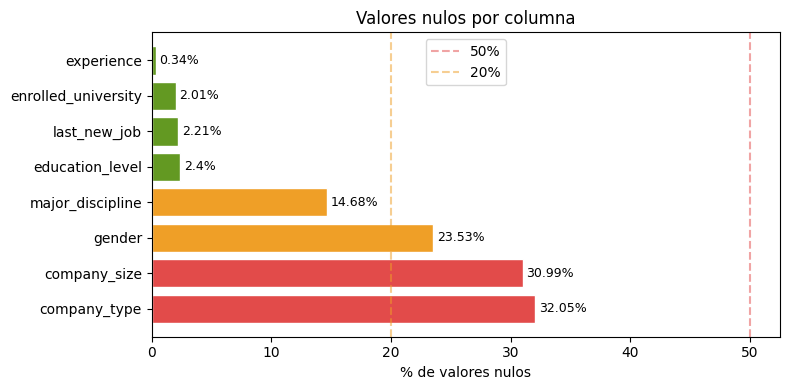

In [26]:
# ─── Visualización del porcentaje de faltantes ────────────────────────────────
# Un gráfico de barras permite ver de un vistazo qué variables están más afectadas.
# Las líneas de referencia al 50% y 20% ayudan a clasificar la gravedad:
# - >50%: considerar eliminar la columna o crear un indicador binario
# - 20-50%: imputación necesaria, elegir estrategia con cuidado
# - <5%: imputación simple suele ser suficiente

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#E24B4A' if p > 25 else '#EF9F27' if p > 10 else '#639922'
          for p in missing['porcentaje']]
bars = ax.barh(missing.index, missing['porcentaje'], color=colors, edgecolor='white')
ax.set_xlabel('% de valores nulos')
ax.set_title('Valores nulos por columna')
ax.axvline(x=50, color='#E24B4A', linestyle='--', alpha=0.5, label='50%')
ax.axvline(x=20, color='#EF9F27', linestyle='--', alpha=0.5, label='20%')
for bar, pct in zip(bars, missing['porcentaje']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

**Observación**: Varias variables con valores perdidos. Ahora sabemos que existe el problema. 
Revisar en la sección Imputación de valores perdidos decidiremos cómo imputarlo con información extra que obtendremos del EDA.

### 1.3 Estadísticos descriptivos — variables numéricas

In [52]:
# Eliminar columnas enrollee_id y target
data.drop(columns=['enrollee_id', 'target'], inplace=True)
data.describe().round(2)

,city_development_index,training_hours
count,19158.00,19158.00
mean,0.83,65.37
std,0.12,60.06
min,0.45,1.00
25%,0.74,23.00
50%,0.90,47.00
75%,0.92,88.00
max,0.95,336.00


**Puntos clave del resumen descriptivo:**

1. **`training_hours` — máximo de 336.00**: No tiene porque estar mal, puede ser que los empleados necesiten esas horas de formación. Eso sí, nos dara una distribución muy sesgada hacia la derecha.
2. **`city_development_index`**: asimetría negativa con cola hacia valores bajos.

In [28]:
print('=== ESTADISTICAS NUMERICAS ===')
data.describe(include='object').T

=== ESTADISTICAS NUMERICAS ===


,count,unique,top,freq
city,19158,123,city_103,4355
gender,14650,3,Male,13221
relevent_experience,19158,2,Has relevent experience,13792
enrolled_university,18772,3,no_enrollment,13817
education_level,18698,5,Graduate,11598
major_discipline,16345,6,STEM,14492
experience,19093,22,>20,3286
company_size,13220,8,50-99,3083
company_type,13018,6,Pvt Ltd,9817
last_new_job,18735,6,1,8040


### 1.4 Distribución de variables numéricas — histogramas y boxplots

#### ¿Qué hacemos aquí?
Analizamos cada variable por separado. El objetivo es entender:
- **La forma de la distribución**: ¿simétrica? ¿asimétrica? ¿bimodal?
- **La presencia de outliers**: ¿hay valores extremos que se alejan mucho del grueso?
- **La distribución de la variable categórica**: ¿están bien balanceadas las categorías?

#### ¿Por qué es importante?
La forma de la distribución determina qué transformaciones son apropiadas. Una distribución muy asimétrica puede perjudicar a ciertos modelos (la regresión lineal asume que los residuos son normales). Los outliers extremos distorsionan el escalado y afectan al entrenamiento.

**Excluimos `enrolle_id` y `target`** de los histogramas y boxplots.

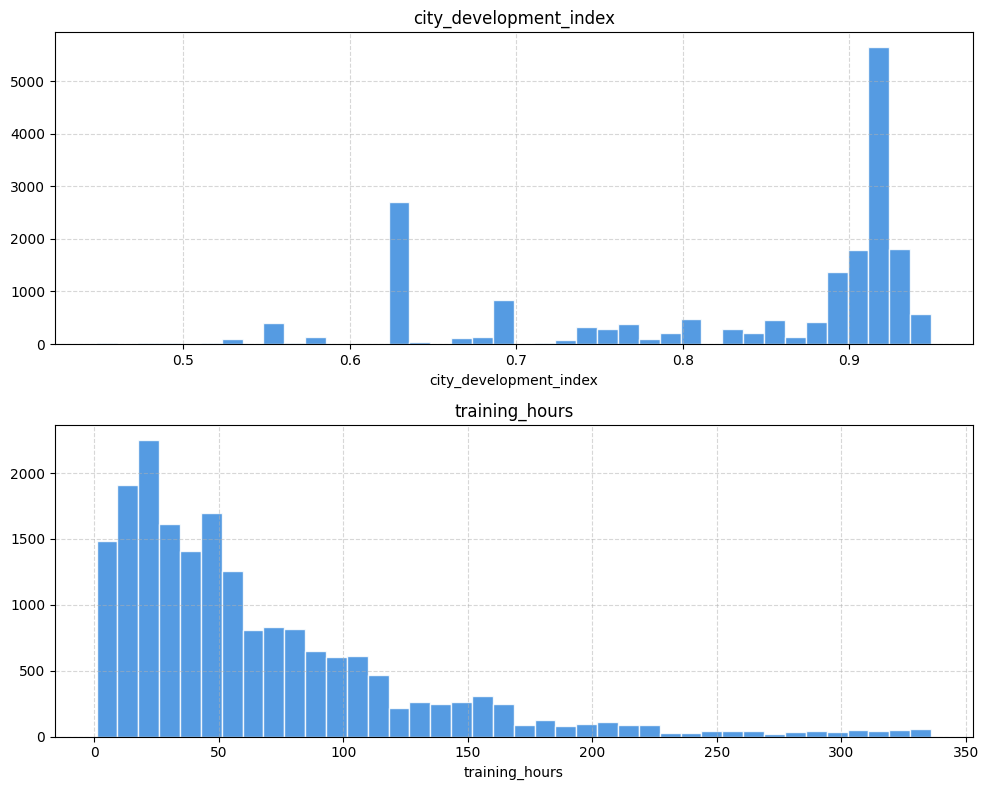

In [29]:
num_vars = ['city_development_index', 'training_hours']

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

for i, var in enumerate(num_vars):
    axes[i].hist(
        data[var].dropna(),
        bins=40,
        color='#378ADD',
        edgecolor='white',
        alpha=0.85
    )
    axes[i].set_title(f'{var}')
    axes[i].set_xlabel(var)
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Observaciones de los histogramas:**
- `city_development_index`. Se aprecian dos "jorobas" separadas. Una concrentración en valores altos (superando ligeramente 0.90) y otra en valores medios-bajos (algo menos de 0.65). Podemos deducir que muchos candidatos vienen de dos tipo de ciudades bien diferenciadas: muy desarrolladas o poco desarrolladas, con pocos casos de ciudades intermedias. Se puede decir que la cola es haza la izquierda (asimetría negativa).
- `training_hours`. La mayoría de los candidatos tienen pocas horas y hay una cola larga hacia valores altos, es una distribución sesgada hacia la derecha.

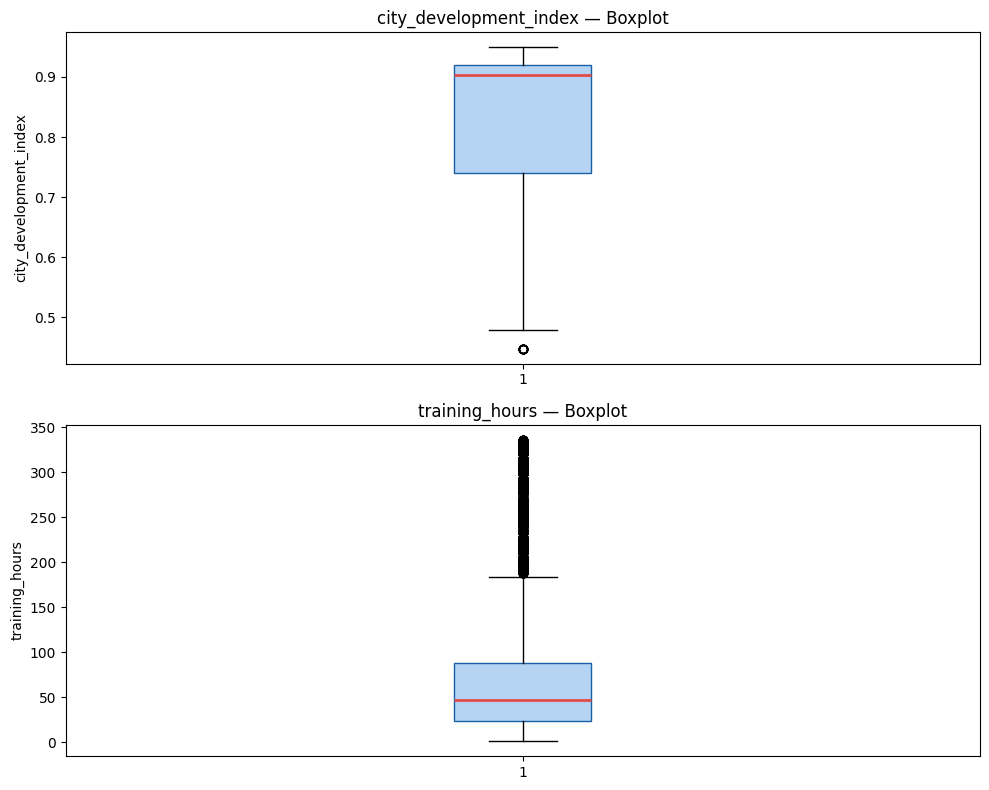

In [30]:
num_vars = ['city_development_index', 'training_hours']

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

for i, var in enumerate(num_vars):
    # Boxplot
    axes[i].boxplot(data[var].dropna(), vert=True, patch_artist=True,
                       boxprops=dict(facecolor='#B5D4F4', color='#185FA5'),
                       medianprops=dict(color='#E24B4A', linewidth=2))
    axes[i].set_title(f'{var} — Boxplot')
    axes[i].set_ylabel(var)

plt.tight_layout()
plt.show()

Observaciones de los boxplots:

- `city_development_index`:  La caja (P25–P75) es grande. Los bigotes cubren bien el rango de valores reales.
- `training hours`: La caja (P25–P75) es pequeña pero hay una cola enorme hacia arriba. Los puntos son outliers visuales. Estos valores extremos distorsionarán el escalado y pueden afectar al entrenamiento — los trataremos en la sección *Tratamiento de outliers*.

### 1.5 Distribución de variables categóricas

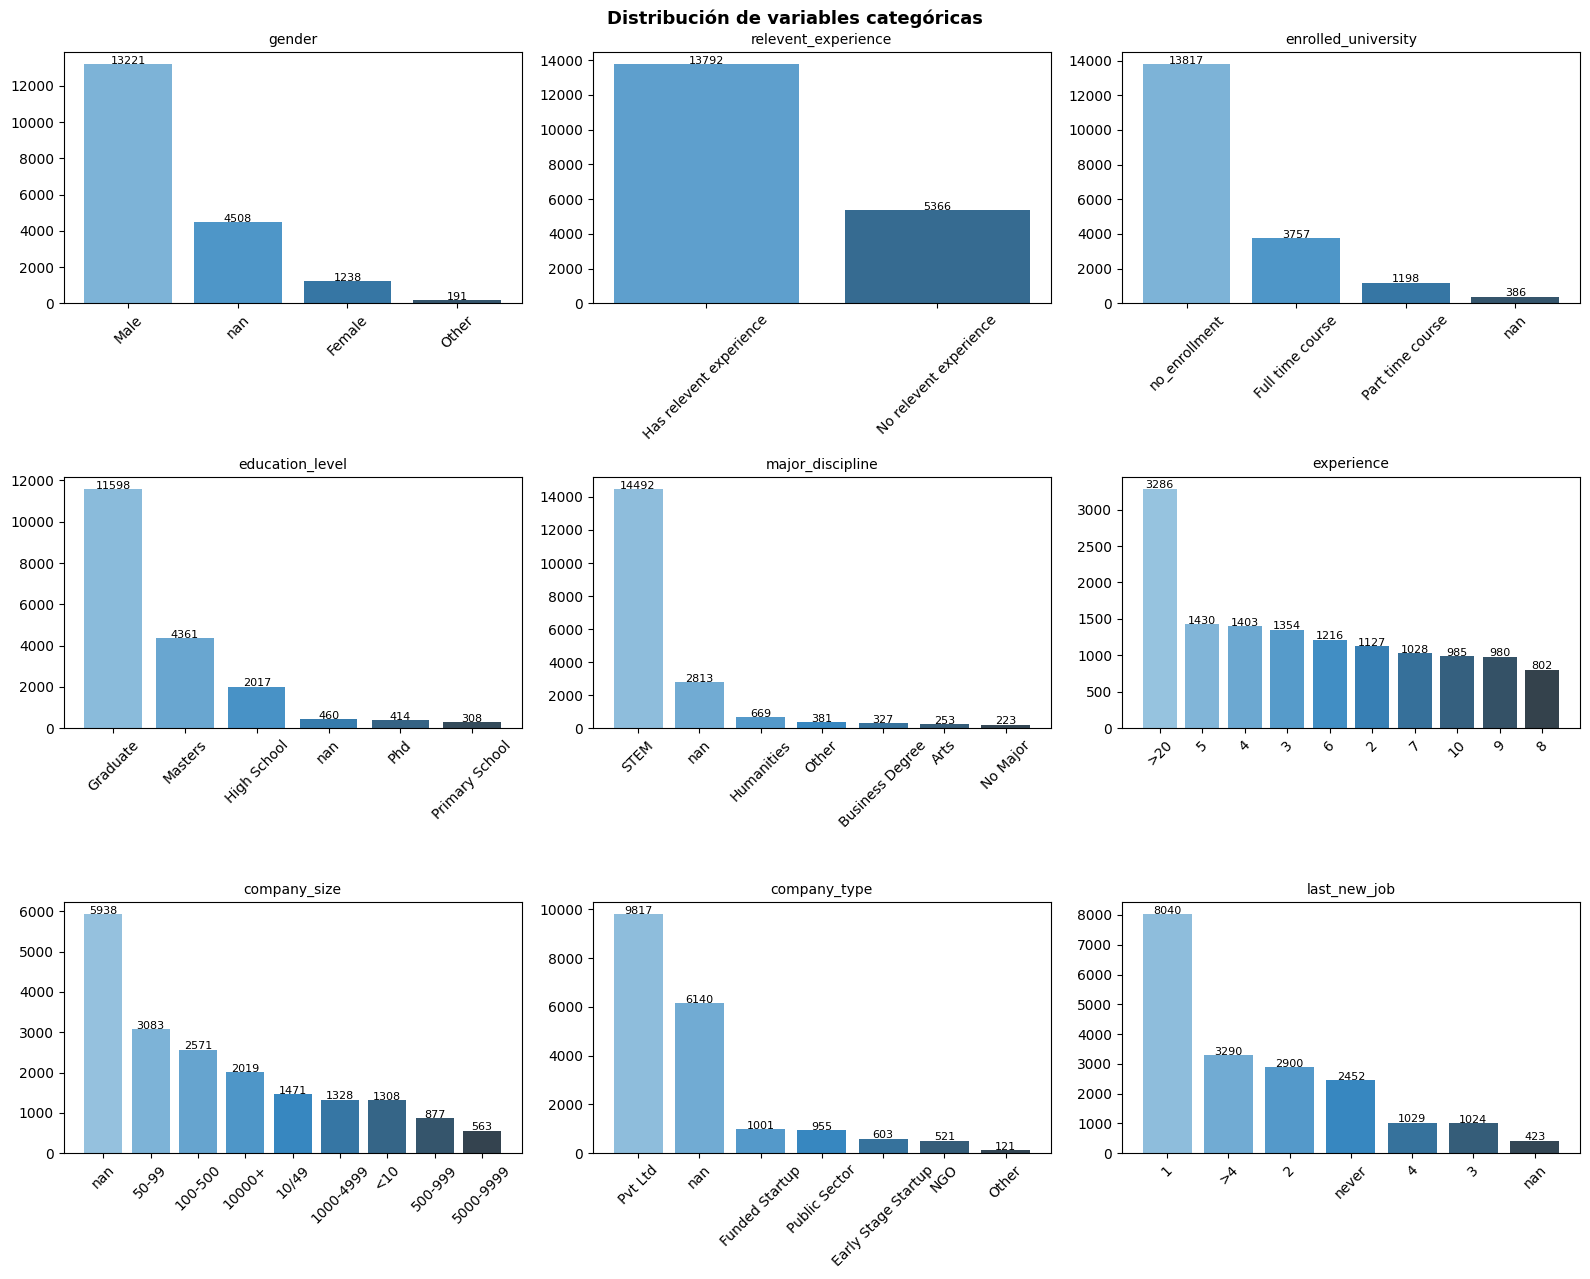

In [31]:
cat_vars = [
    'gender', 'relevent_experience', 'enrolled_university',
    'education_level', 'major_discipline', 'experience',
    'company_size', 'company_type', 'last_new_job'
]

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

for i, var in enumerate(cat_vars):
    counts = data[var].value_counts(dropna=False).head(10)
    colors = sns.color_palette('Blues_d', len(counts))

    axes[i].bar(counts.index.astype(str), counts.values, color=colors)
    axes[i].set_title(f'{var}', fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)

    # Etiquetas encima de cada barra
    for j, (val, name) in enumerate(zip(counts.values, counts.index.astype(str))):
        axes[i].text(j, val + 5, str(val), ha='center', fontsize=8)

plt.suptitle('Distribución de variables categóricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Observaciones de los barplots.

Destacan:

- `gender`: La categoría "Male" domina sobre "Female" y "Other".
- `major_discipline`: "STEM" domina sobre las otras disciplinas.
- `company_size` y `company_type` tienen muchos nulos.
- `education_level`: "Graduate" nivel más habitual.

---
## 2. Estudio de las relaciones entre las variables

### ¿Qué hacemos aquí?
Analizamos las relaciones entre pares de variables, con foco especial en la relación de cada variable con **target**?. Los análisis bivariados incluyen:
- **Matriz de correlaciones de Pearson**: para variables numéricas y ordinales
- **Boxplots del target por categorías**: para variables numéricas

### ¿Por qué es importante?
Las correlaciones nos indican qué variables tienen relación lineal con el target — señal de que serán predictores útiles. También detectamos **multicolinealidad** entre predictores (variables que miden lo mismo), lo que motivará la creación de ratios en el feature engineering.

### 2.1 Matriz de correlaciones — heatmap

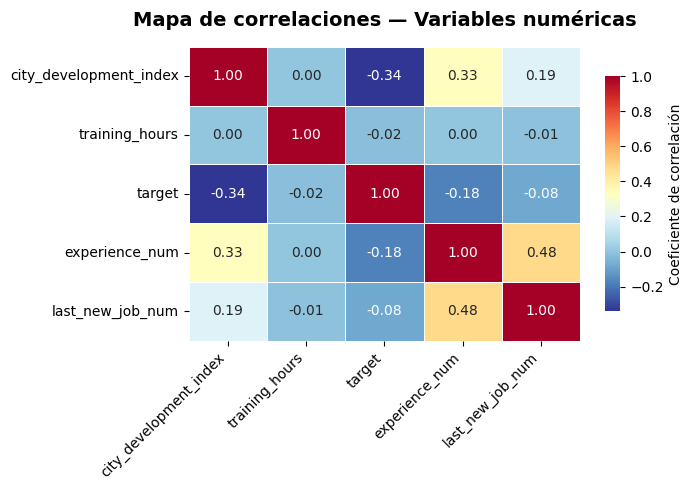

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

num_data = data[['city_development_index', 'training_hours', 'target']].copy()

# Añadimos las ordinales codificadas numéricamente para ver correlaciones
exp_map = {'<1':0,'1':1,'2':2,'3':3,'4':4,'5':5,'6':6,'7':7,'8':8,'9':9,
           '10':10,'11':11,'12':12,'13':13,'14':14,'15':15,'16':16,'17':17,
           '18':18,'19':19,'20':20,'>20':21}
lnj_map = {'never':0,'1':1,'2':2,'3':3,'4':4,'>4':5}

num_data['experience_num']     = data['experience'].map(exp_map)
num_data['last_new_job_num']   = data['last_new_job'].map(lnj_map)

corr_matrix = num_data.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",          # paleta más equilibrada
    linewidths=0.5,           # líneas divisorias suaves
    cbar_kws={'shrink': 0.8, 'aspect': 15, 'label': 'Coeficiente de correlación'}
)

plt.title('Mapa de correlaciones — Variables numéricas', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()



**Lecturas clave de la matriz de correlaciones:**


Con el target:
- `city_development_index` correlación ≈−0.34 - es la variable más predictiva por sí sola. A mayor índice de desarrollo de la ciudad, menor probabilidad de buscar cambio.
- `experience_num` correlación ≈−0.18 - moderamente negativa. A más años de experiencia, menos probabilidad de buscar cambio.
- `last_new_job_num` correlación ≈−0.08 - débilmente negativa. Candidatos con años en el puesto tienden a buscar menos el cambio.
- `training_hours` correlación ≈-0.02 - casi cero. Las horas de formación no predicen el cambio de trabajo.

Entre predictores (multicolinealidad):
- `experience_num`, `last_new_job_num` correlación ≈0.48 - moderada positiva. Cuantos más años de experiencia tenga el empleado, tiene sentido que lleve más tiempo en el último empleo.
- `city_development_index` y `experience_num` correlación ≈0.33 - tienen cierta correlación entre sí. Las ciudades más desarrolladas suelen tener perfiles con más experiencia.

### 2.2 Relaciones entre variables categóricas y target — barplots apilados

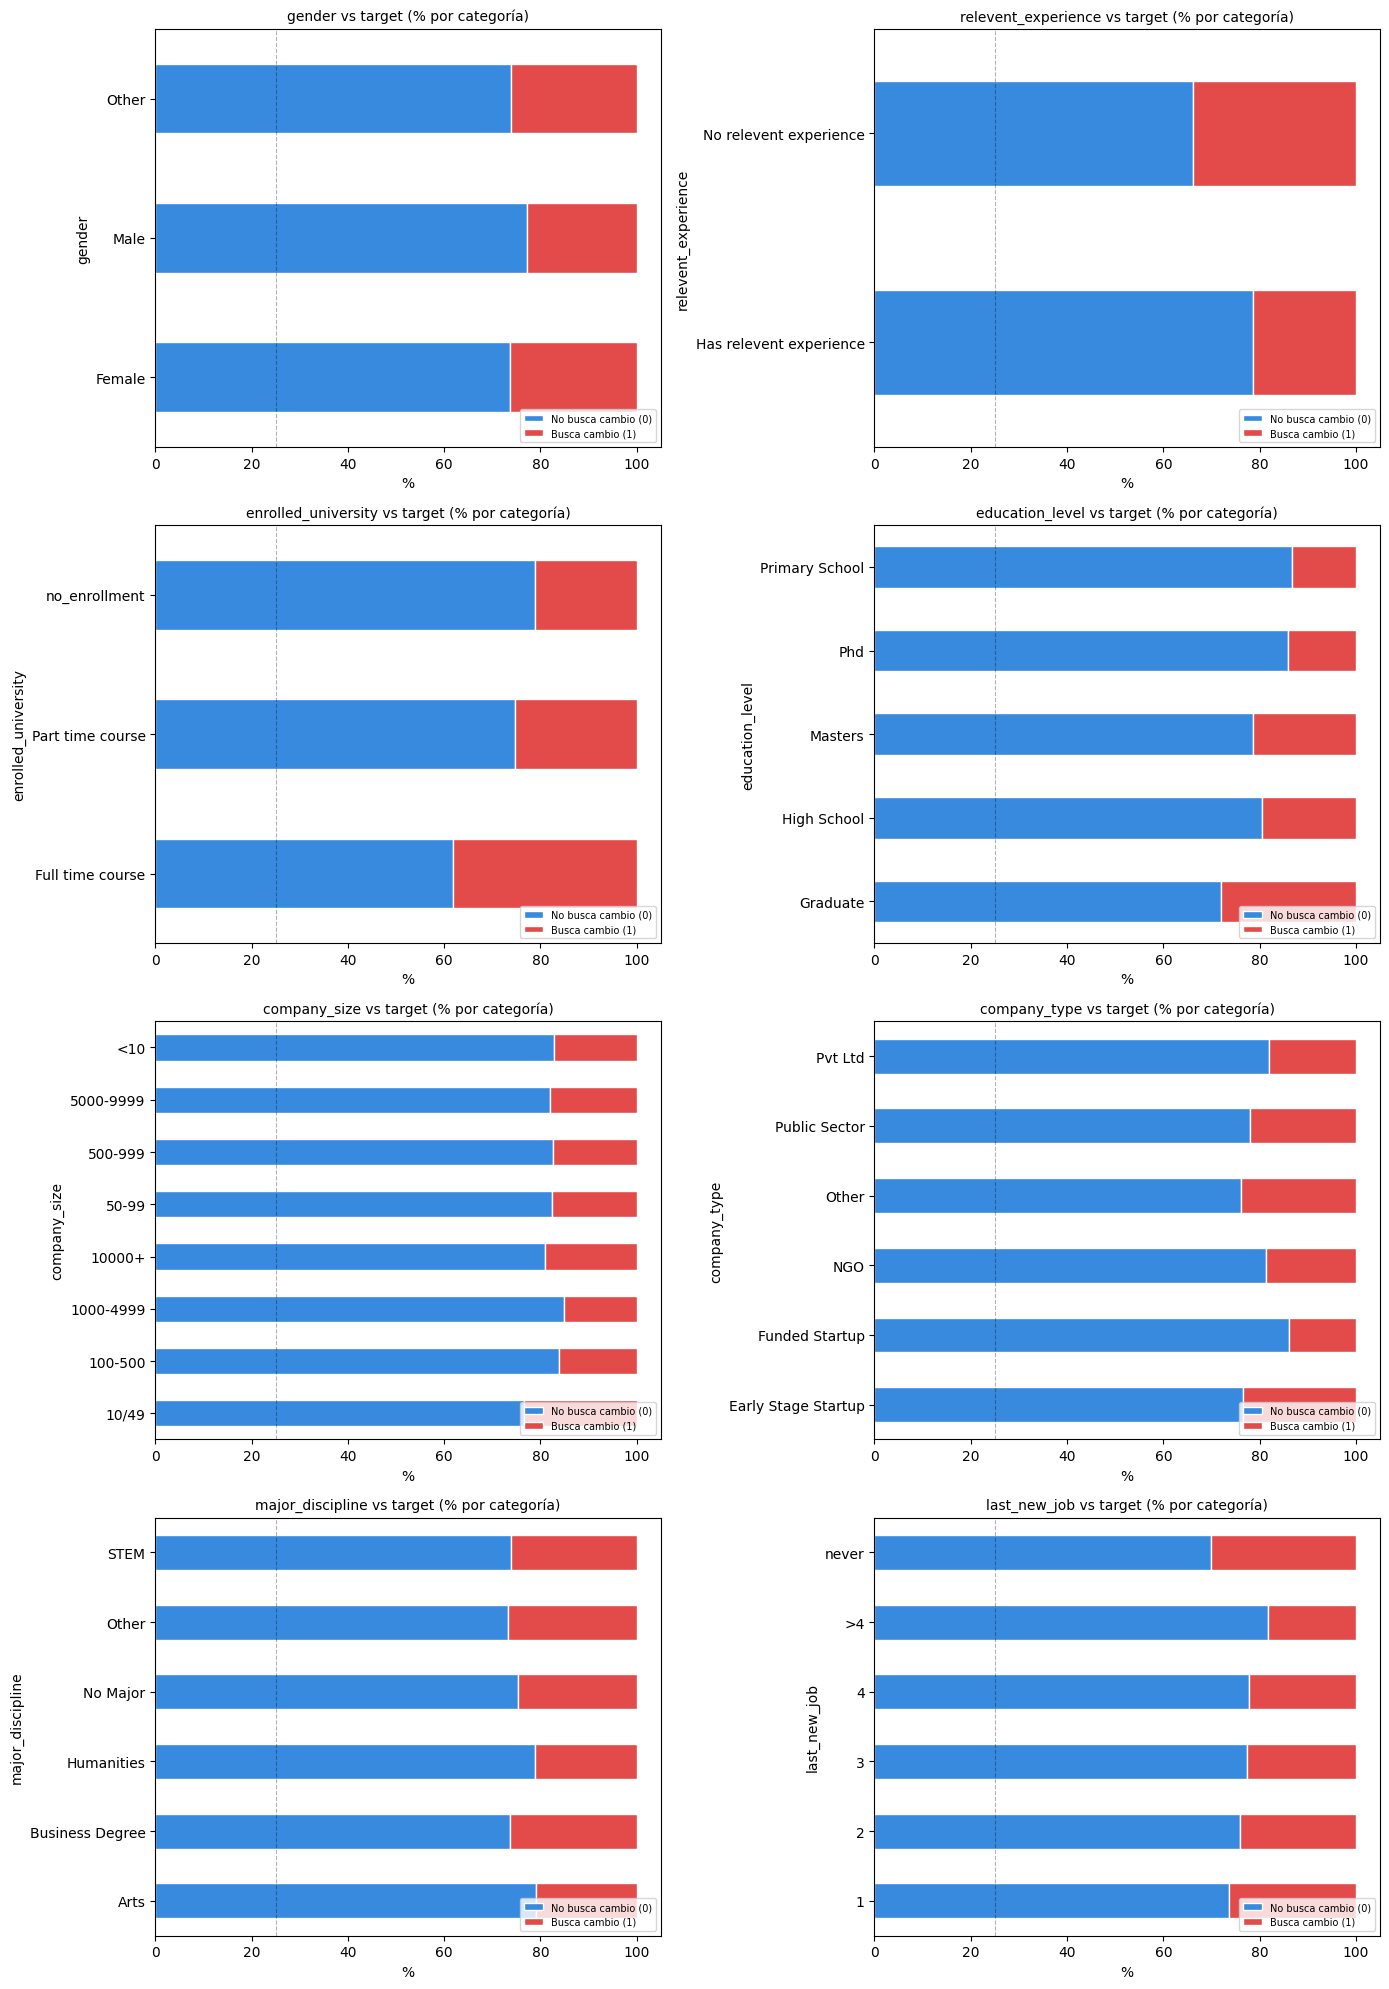

In [33]:
cat_vs_target = [
    'gender', 'relevent_experience', 'enrolled_university',
    'education_level', 'company_size', 'company_type',
    'major_discipline', 'last_new_job'
]

fig, axes = plt.subplots(4, 2, figsize=(14, 20))
axes = axes.flatten()

for i, var in enumerate(cat_vs_target):
    ct = pd.crosstab(data[var], data['target'], normalize='index') * 100
    ct.columns = ['No busca cambio (0)', 'Busca cambio (1)']
    ct.plot(kind='barh', stacked=True, ax=axes[i],
            color=['#378ADD', '#E24B4A'], edgecolor='white')
    axes[i].set_title(f'{var} vs target (% por categoría)', fontsize=10)
    axes[i].set_xlabel('%')
    axes[i].axvline(x=25, color='black', linestyle='--', alpha=0.3, linewidth=0.8)
    axes[i].legend(loc='lower right', fontsize=7)

plt.tight_layout()
plt.show()

Interpretación de barplots apilados:
- `enrolled_university`: Aquellos que están en la universidad a tiempo completo buscan un cambio bastante frecuente (casi el 40%)
- `relevent_experience`: Los empleados que no tiene experiencia relevante tienden a buscar más el cambio.
- `last_new_job`: Aquellos que no han tenido trabajo anterior pues lo buscan y según van encadenando trabajos, buscan menos el cambio. 

---
## 4. Tratamiento de outliers

### ¿Qué hacemos aquí?
Identificamos y eliminamos valores extremos en las variables numéricas usando el método IQR (rango intercuartílico).

### El método IQR
Para cada variable:
- $Q1$ = percentil 25, $Q3$ = percentil 75, $IQR = Q3 - Q1$
- Límite inferior: $Q1 - k \times IQR$
- Límite superior: $Q3 + k \times IQR$
- Se eliminan las **filas** donde cualquier variable supera estos límites

In [34]:
def detectar_outliers_iqr(serie, factor=1.5):
    """Devuelve mascara booleana True para outliers y los limites."""
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - factor * IQR
    limite_sup = Q3 + factor * IQR
    mask = (serie < limite_inf) | (serie > limite_sup)
    return mask, limite_inf, limite_sup


for col in ['training_hours']:
    serie = data[col].dropna()
    mask, li, ls = detectar_outliers_iqr(serie)
    n_out = mask.sum()
    pct   = mask.mean() * 100
    print(f'{col}:')
    print(f'  Limites IQR: [{li:,.0f} , {ls:,.0f}]')
    print(f'  Outliers: {n_out:,} ({pct:.1f}%)')
    print(f'  Valor maximo: {serie.max():,.0f}')
    print()

training_hours:
  Limites IQR: [-74 , 186]
  Outliers: 984 (5.1%)
  Valor maximo: 336



In [35]:
# Analizar outliers de Training hours: son errores o casos validos?
data_final_training_hours = data[['training_hours', 'experience', 'company_type', 'target']].copy()

mask_hours, li_hours, ls_hours = detectar_outliers_iqr(data_final_training_hours['training_hours'])
data_final_training_hours = data_final_training_hours.copy()
data_final_training_hours['es_outlier'] = mask_hours.values

print('Top 10 registros con más training_hours (outliers superiores):')
print(
    data_final_training_hours[data_final_training_hours['es_outlier']]
      .sort_values('training_hours', ascending=False)
      .head(10)
      .to_string(index=False)
)

Top 10 registros con más training_hours (outliers superiores):
 training_hours experience        company_type  target  es_outlier
            336          3             Pvt Ltd     0.0        True
            336         16 Early Stage Startup     0.0        True
            336          3             Pvt Ltd     1.0        True
            336          5             Pvt Ltd     0.0        True
            336          2       Public Sector     0.0        True
            336         <1                 NaN     1.0        True
            336          6                 NaN     0.0        True
            336          5             Pvt Ltd     0.0        True
            336         15                 NaN     1.0        True
            336         12             Pvt Ltd     0.0        True


In [36]:
print()
print('Tipo de compañía entre outliers de training_hours:')
print(data_final_training_hours[data_final_training_hours['es_outlier']]['company_type'].value_counts())


Tipo de compañía entre outliers de training_hours:
company_type
Pvt Ltd                518
Funded Startup          53
Public Sector           39
Early Stage Startup     38
NGO                     30
Other                    5
Name: count, dtype: int64


### 4.1 — Decisión: ¿qué hacemos con los outliers?

Podemos considerar que las horas de training extremas son **reales**, no son errores de medición. Las opciones:

- **Eliminar**: Si solo nos interesan empleados con ciertas horas de training.
- **Winsorizar (cap)**: Limitar al percentil 99 — mantiene el dato pero controla el extremo
- **Transformación log**: Comprime la cola derecha sin eliminar datos

In [37]:
# Tratamiento de outliers en training_hours
# Opción elegida: Winsorización (cap en el percentil 99)
# Justificación: los outliers son reales (alguien puede haber tomado 300+ horas),
# eliminarlos perdería datos; la winsorización reduce su influencia sin descartarlos.
data_clean = data.copy()

p99 = data_clean['training_hours'].quantile(0.99)
print(f'Percentil 99 de training_hours: {p99:.1f}')

data_clean['training_hours'] = data_clean['training_hours'].clip(upper=p99)

print(f'training_hours después de winsorización:')
print(f'  Max: {data_clean["training_hours"].max()}')
print(f'  Media: {data_clean["training_hours"].mean():.2f}')

# city_development_index: no tiene outliers significativos (datos acotados [0,1])
print('\ncity_development_index: sin tratamiento necesario (rango acotado [0,1])')

Percentil 99 de training_hours: 302.0
training_hours después de winsorización:
  Max: 302
  Media: 65.19

city_development_index: sin tratamiento necesario (rango acotado [0,1])


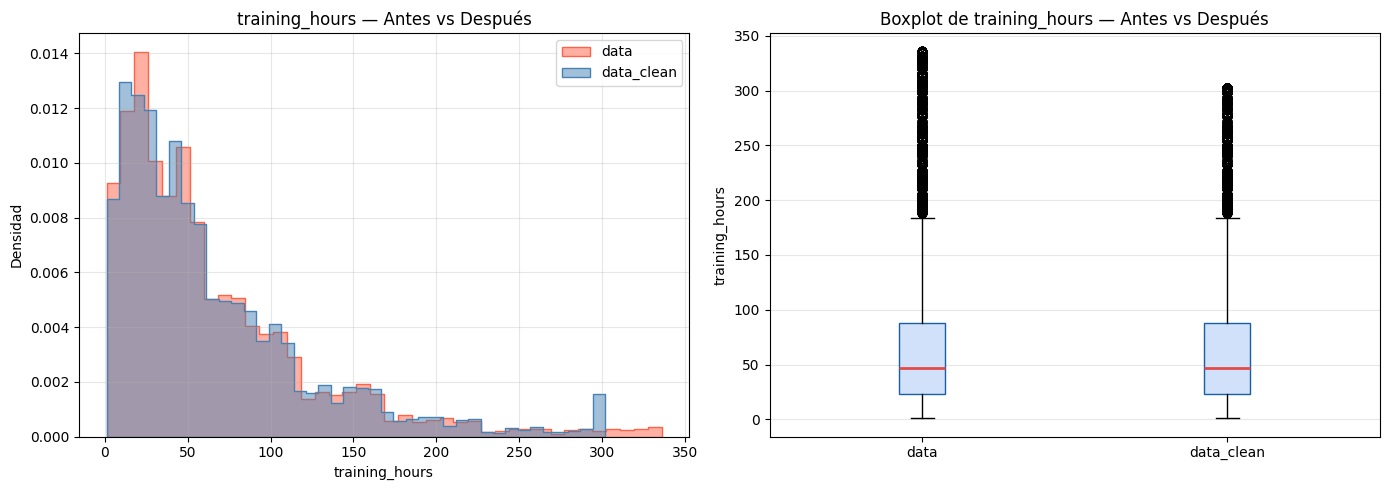

In [38]:
# Comparación clara entre data y data_clean
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma superpuesto para comparar la distribución antes y después del cap
sns.histplot(data['training_hours'].dropna(), bins=40, color='tomato', alpha=0.5,
             label='data', stat='density', element='step', ax=axes[0])
sns.histplot(data_clean['training_hours'].dropna(), bins=40, color='steelblue', alpha=0.5,
             label='data_clean', stat='density', element='step', ax=axes[0])
axes[0].set_title('training_hours — Antes vs Después')
axes[0].set_xlabel('training_hours')
axes[0].set_ylabel('Densidad')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Boxplots para ver el efecto sobre la mediana y los valores extremos
axes[1].boxplot([data['training_hours'].dropna(), data_clean['training_hours'].dropna()],
                labels=['data', 'data_clean'], patch_artist=True,
                boxprops=dict(facecolor='#D0E1F9', color='#185FA5'),
                medianprops=dict(color='#E24B4A', linewidth=2))
axes[1].set_title('Boxplot de training_hours — Antes vs Después')
axes[1].set_ylabel('training_hours')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 5. Imputación de valores perdidos

Existen tres tipos de datos faltantes:

- MCAR (Missing Completely At Random). El dato falta por razones aleatorias.
- MAR (Missing At Random). El datos falta por razones relacionadas con otras variables observadas.
- MNAR (Missing Not At Random). El dato falta precisamente por su valor, el nulo en sí mismo es información. 

`company_size` y `company_type`son MNAR: si alguien no está trabajando, no puede rellenar esos campos. Para ellos se debe crear una nueva categoría.

In [39]:
# - >50%: considerar eliminar la columna o crear un indicador binario
# - 20-50%: imputación necesaria, elegir estrategia con cuidado
# - <5%: imputación simple suele ser suficiente

# company_size y company_type (≈32% de nulos):  indican candidato sin empleo actual.
# así que creamos una categoría 'Not employed' para preservar esta información.
data_clean['company_size'].fillna('Not employed', inplace=True)
data_clean['company_type'].fillna('Not employed', inplace=True)
print("company_size y company_type: imputados con categoría 'Not employed'")

# gender (≈23% de nulos): indican que el candidato no quiso revelar su género. 
# Creamos categoría 'Unknown' para preservar esta información, si asignaramos
# la moda (masculino) asignaríamos erróneamente un género a quienes no lo revelaron.
data_clean['gender'].fillna('Unknown', inplace=True)
print("gender: imputado con categoría 'Unknown'")

# major_discipline (≈15% de nulos): indican que el candidato no tiene formación superior.
# Asignamos los nulos a la categoría 'No major' para reflejar esta realidad, e
# en lugar de imputar con la moda (STEM) que sería incorrecto.
data_clean['major_discipline'].fillna('No major', inplace=True)
print("major_discipline: imputado con categoría 'No major'")

# Resto (< 2.5% de nulos): imputación por moda
for col in ['enrolled_university', 'education_level', 'experience', 'last_new_job']:
    moda = data_clean[col].mode()[0]
    data_clean[col].fillna(moda, inplace=True)
    print(f"{col}: imputado con moda '{moda}'")

print(f'\nNulos restantes: {data_clean.isnull().sum().sum()}')

company_size y company_type: imputados con categoría 'Not employed'
gender: imputado con categoría 'Unknown'
major_discipline: imputado con categoría 'No major'
enrolled_university: imputado con moda 'no_enrollment'
education_level: imputado con moda 'Graduate'
experience: imputado con moda '>20'
last_new_job: imputado con moda '1'

Nulos restantes: 0


---
## 6. Tratamiento de variables categóricas

In [40]:
cat_cols = data_clean.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != 'target']

print('Cardinalidad de variables categóricas:')
print('=' * 50)
for col in cat_cols:
    n = data_clean[col].nunique()
    vals = data_clean[col].unique()[:5]
    print(f"  {col:<30} {n:>3} categorías | Ej: {list(vals)}")

Cardinalidad de variables categóricas:
  city                           123 categorías | Ej: ['city_103', 'city_40', 'city_21', 'city_115', 'city_162']
  gender                           4 categorías | Ej: ['Male', 'Unknown', 'Female', 'Other']
  relevent_experience              2 categorías | Ej: ['Has relevent experience', 'No relevent experience']
  enrolled_university              3 categorías | Ej: ['no_enrollment', 'Full time course', 'Part time course']
  education_level                  5 categorías | Ej: ['Graduate', 'Masters', 'High School', 'Phd', 'Primary School']
  major_discipline                 7 categorías | Ej: ['STEM', 'Business Degree', 'No major', 'Arts', 'Humanities']
  experience                      22 categorías | Ej: ['>20', '15', '5', '<1', '11']
  company_size                     9 categorías | Ej: ['Not employed', '50-99', '<10', '10000+', '5000-9999']
  company_type                     7 categorías | Ej: ['Not employed', 'Pvt Ltd', 'Funded Startup', 'Early

In [41]:
# city tiene alta cardinalidad (ej. 123 ciudades)
# → Descartamos city y conservamos city_development_index (captura la info geográfica)
print(f"Cardinalidad de 'city': {data_clean['city'].nunique()} ciudades")
print("→ Se descarta 'city'. city_development_index ya captura la información geográfica.")

data_clean.drop(columns=['enrollee_id', 'city'], inplace=True)
print(f"\nColumnas tras eliminar ID y city: {list(data_clean.columns)}")

Cardinalidad de 'city': 123 ciudades
→ Se descarta 'city'. city_development_index ya captura la información geográfica.

Columnas tras eliminar ID y city: ['city_development_index', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job', 'training_hours', 'target']


In [42]:
# Variables ordinales: preservar el orden semántico con OrdinalEncoder

exp_order    = ['<1','1','2','3','4','5','6','7','8','9','10',
                '11','12','13','14','15','16','17','18','19','20','>20']
edu_order    = ['Primary School','High School','Graduate','Masters','Phd']
size_order   = ['Not employed','<10','10/49','50-99','100-500',
                '500-999','1000-4999','5000-9999','10000+']
lnj_order    = ['never','1','2','3','4','>4']

oe = OrdinalEncoder(
    categories=[exp_order, edu_order, size_order, lnj_order],
    handle_unknown='use_encoded_value', unknown_value=-1
)

ordinal_cols = ['experience', 'education_level', 'company_size', 'last_new_job']
data_clean[ordinal_cols] = oe.fit_transform(data_clean[ordinal_cols])

print('Encoding ordinal aplicado:')
for col, cats in zip(ordinal_cols, oe.categories_):
    print(f"  {col}: {list(cats)} → [0, {len(cats)-1}]")

Encoding ordinal aplicado:
  experience: ['<1', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '>20'] → [0, 21]
  education_level: ['Primary School', 'High School', 'Graduate', 'Masters', 'Phd'] → [0, 4]
  company_size: ['Not employed', '<10', '10/49', '50-99', '100-500', '500-999', '1000-4999', '5000-9999', '10000+'] → [0, 8]
  last_new_job: ['never', '1', '2', '3', '4', '>4'] → [0, 5]


In [43]:
# relevent_experience: binaria → 0 / 1
data_clean['relevent_experience'] = data_clean['relevent_experience'].map({
    'Has relevent experience': 1,
    'No relevent experience': 0
})
print('relevent_experience:', data_clean['relevent_experience'].value_counts().to_dict())

relevent_experience: {1: 13792, 0: 5366}


---
## 7. Feature Engineering


In [44]:
# Feature 1: interacción CDI × experiencia
data_clean['cdi_x_exp'] = data_clean['city_development_index'] * data_clean['experience']

# Feature 2: flag candidato en curso a tiempo completo
data_clean['is_fulltime_course'] = (data_clean['enrolled_university'] == 'Full time course').astype(int)

print('Nuevas features añadidas:')
print(f"  cdi_x_exp — estadísticos: media={data_clean['cdi_x_exp'].mean():.3f}, std={data_clean['cdi_x_exp'].std():.3f}")
print(f"  is_fulltime_course — distribución: {data_clean['is_fulltime_course'].value_counts().to_dict()}")

Nuevas features añadidas:
  cdi_x_exp — estadísticos: media=8.678, std=6.224
  is_fulltime_course — distribución: {0: 15401, 1: 3757}


- `cdi_x_exp`: Variable que mide la combinación de `city_development_index` y `experience`. Como habías deduccido de la matriz de correlación, cuantó más aumentaban ambas variables, menor era la búsqueda de trabajo.
- `is_full_time_course`: Variable que mide si un candidato está en un curso a tiempo completo. Es interesante porque habíamos apreciado que un número importante de candidatos que estaban a tiempo completo, buscaban nuevo trabajo.

---
## 8. Preparación final: OHE, Split y Escalado ???

---
### 8.1 One-Hot Encoding de variables nominales

El OHE transforma las 4 variables nominales en columnas binarias. 
Por ejemplo, para `gender` (4 categorías): ['Female', 'Male', 'Other', 'Unknown'], se convierten en cuatro columnas nuevas.

In [45]:
nominal_features = ['gender', 'enrolled_university', 'major_discipline', 'company_type']

print('Categorías por variable nominal (tras imputación):')
for col in nominal_features:
    cats = sorted(data_clean[col].unique())
    print(f'  {col} ({len(cats)} categorías): {cats}')

Categorías por variable nominal (tras imputación):
  gender (4 categorías): ['Female', 'Male', 'Other', 'Unknown']
  enrolled_university (3 categorías): ['Full time course', 'Part time course', 'no_enrollment']
  major_discipline (7 categorías): ['Arts', 'Business Degree', 'Humanities', 'No Major', 'No major', 'Other', 'STEM']
  company_type (7 categorías): ['Early Stage Startup', 'Funded Startup', 'NGO', 'Not employed', 'Other', 'Public Sector', 'Pvt Ltd']


In [46]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Ajustar y transformar
ohe_array = ohe.fit_transform(data_clean[nominal_features])
ohe_cols  = ohe.get_feature_names_out(nominal_features)
df_ohe    = pd.DataFrame(ohe_array, columns=ohe_cols, index=data_clean.index)

# Eliminar columnas originales y añadir las nuevas
df_final = pd.concat([data_clean.drop(columns=nominal_features), df_ohe], axis=1)

print(f'Dimensiones antes del OHE : {data_clean.shape}')
print(f'Dimensiones después del OHE: {df_final.shape}')
print(f'Columnas OHE generadas     : {len(ohe_cols)}')
print(f'\nColumnas nuevas:')
for col in ohe_cols:
    print(f'  {col}')

Dimensiones antes del OHE : (19158, 14)
Dimensiones después del OHE: (19158, 31)
Columnas OHE generadas     : 21

Columnas nuevas:
  gender_Female
  gender_Male
  gender_Other
  gender_Unknown
  enrolled_university_Full time course
  enrolled_university_Part time course
  enrolled_university_no_enrollment
  major_discipline_Arts
  major_discipline_Business Degree
  major_discipline_Humanities
  major_discipline_No Major
  major_discipline_No major
  major_discipline_Other
  major_discipline_STEM
  company_type_Early Stage Startup
  company_type_Funded Startup
  company_type_NGO
  company_type_Not employed
  company_type_Other
  company_type_Public Sector
  company_type_Pvt Ltd


In [47]:
# Verificación: no deben quedar nulos ni columnas de texto
print(f'Nulos tras OHE: {df_final.isnull().sum().sum()}')
print(f'Columnas de tipo object: {list(df_final.select_dtypes(include="object").columns)}')
print(f'\nPrimeras filas del dataset tras OHE:')
df_final.head(3)

Nulos tras OHE: 0
Columnas de tipo object: []

Primeras filas del dataset tras OHE:


,city_development_index,relevent_experience,education_level,experience,company_size,last_new_job,training_hours,target,cdi_x_exp,is_fulltime_course,...,major_discipline_No major,major_discipline_Other,major_discipline_STEM,company_type_Early Stage Startup,company_type_Funded Startup,company_type_NGO,company_type_Not employed,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd
0,0.920,1,2.0,21.0,0.0,1.0,36,1.0,19.32,0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.776,0,2.0,15.0,3.0,5.0,47,0.0,11.64,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.624,0,2.0,5.0,0.0,0.0,83,0.0,3.12,1,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


---
### 8.2. División train/test estratificada

Dividimos en **tres** conjuntos:
- **Train** (~70%): el modelo aprende aqui
- **Validation** (~15%): comparamos estrategias y ajustamos
- **Test** (~15%): evaluacion final, se usa **una sola vez**

In [48]:
X = df_final.drop(columns=['target'])
y = df_final['target'].astype(int)

# Paso 1: separar TEST del resto (15%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Paso 2: separar TRAIN de VALIDATION (15% del resto ≈ 10% del total)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.15, random_state=42, stratify=y_trainval
)

total = len(X)
print('Distribucion del split:')
print(f'  Train:      {len(X_train):>8,}  ({len(X_train)/total*100:.0f}%)')
print(f'  Validation: {len(X_val):>8,}  ({len(X_val)/total*100:.0f}%)')
print(f'  Test:       {len(X_test):>8,}  ({len(X_test)/total*100:.0f}%)')

print()
print('Tasa de positivos en cada particion (stratify OK si son similares):')
print(f'  Train:      {y_train.mean()*100:.2f}%')
print(f'  Validation: {y_val.mean()*100:.2f}%')
print(f'  Test:       {y_test.mean()*100:.2f}%')

Distribucion del split:
  Train:        13,841  (72%)
  Validation:    2,443  (13%)
  Test:          2,874  (15%)

Tasa de positivos en cada particion (stratify OK si son similares):
  Train:      24.93%
  Validation: 24.93%
  Test:       24.95%


---
## 8.3. Escalado: StandardScaler vs RobustScaler

El escalado se aplica **despues del split**, aprendiendo solo en train.

In [49]:
numeric_features = ['city_development_index', 'training_hours', 'cdi_x_exp']

# Ajustar ambos escaladores SOLO sobre X_train
rs = RobustScaler()

X_train_rs = X_train.copy()

X_train_rs[numeric_features] = rs.fit_transform(X_train[numeric_features])

print('Escaladores ajustados sobre X_train.')
print(f'Parámetros StandardScaler:')
numeric_features = ['city_development_index', 'training_hours', 'cdi_x_exp']

ss = StandardScaler()
rs = RobustScaler()

ss.fit(X_train[numeric_features])
rs.fit(X_train[numeric_features])

X_train_rs = X_train.copy()
X_train_rs[numeric_features] = rs.transform(X_train[numeric_features])

X_train_ss = X_train.copy()
X_train_ss[numeric_features] = ss.transform(X_train[numeric_features])

print('Escaladores ajustados sobre X_train.')
print(f'Parámetros StandardScaler:')
for var, mean, std in zip(numeric_features, ss.mean_, ss.scale_):
    print(f'  {var:<30} media={mean:.4f}, std={std:.4f}')

print(f'\nParámetros RobustScaler:')
for var, center, scale in zip(numeric_features, rs.center_, rs.scale_):
    print(f'  {var:<30} mediana={center:.4f}, IQR={scale:.4f}')

print('\nComparación de resultados tras escalado en X_train:')
print('  StandardScaler deja media ~0 y desviación estándar ~1.')
print('  RobustScaler deja mediana ~0 y IQR ~1, siendo más robusto frente a outliers.')

print('\nResumen de estadísticas tras escalado:')
print(pd.DataFrame({
    'std_mean': X_train_ss[numeric_features].mean().round(4),
    'std_std': X_train_ss[numeric_features].std(ddof=0).round(4),
    'rb_median': X_train_rs[numeric_features].median().round(4),
    'rb_iqr': (X_train_rs[numeric_features].quantile(0.75) - X_train_rs[numeric_features].quantile(0.25)).round(4)
}))
print(f'\nParámetros RobustScaler:')
for var, center, scale in zip(numeric_features, rs.center_, rs.scale_):
    print(f'  {var:<30} mediana={center:.4f}, IQR={scale:.4f}')

Escaladores ajustados sobre X_train.
Parámetros StandardScaler:
Escaladores ajustados sobre X_train.
Parámetros StandardScaler:
  city_development_index         media=0.8298, std=0.1229
  training_hours                 media=64.8363, std=58.8918
  cdi_x_exp                      media=8.7244, std=6.2502

Parámetros RobustScaler:
  city_development_index         mediana=0.9100, IQR=0.1780
  training_hours                 mediana=47.0000, IQR=65.0000
  cdi_x_exp                      mediana=7.1760, IQR=10.3100

Comparación de resultados tras escalado en X_train:
  StandardScaler deja media ~0 y desviación estándar ~1.
  RobustScaler deja mediana ~0 y IQR ~1, siendo más robusto frente a outliers.

Resumen de estadísticas tras escalado:
                        std_mean  std_std  rb_median  rb_iqr
city_development_index      -0.0      1.0        0.0     1.0
training_hours              -0.0      1.0        0.0     1.0
cdi_x_exp                   -0.0      1.0        0.0     1.0

Parámetros Ro

Interpretación de los resultados esperados: para training_hours (distribución muy sesgada con outliers) StandardScaler se desequilibra por los extremos, mientras que RobustScaler reduce la influencia de esos valores extremos.
Recomendación práctica: usar RobustScaler cuando haya outliers o colas largas (como training_hours); si una variable es aproximadamente normal, StandardScaler es adecuado. Siempre fit en X_train y luego transform idéntico en X_val/X_test.

RobustScaler es robusto a outliers.
1. city_development_index: mediana alta (cdi elevado), iqr pequeño (baja dispersión)
2. training_hours: mediana mucho menor que la media (47 vs 65), asimetría fuerte hacia la derecha, iqr grande (variabilidad)
3. cdi_x_exp: variable dispera y asimétrica.

## 9. Resumen del proceso de limpieza y preparación

**Transformaciones aplicadas:**
- Eliminadas: `enrollee_id`, `city` (alta cardinalidad / posible leakage).
- Outliers: winsorización de `training_hours` al percentil 99 para limitar extremos sin perder registros.
- Imputación: `company_size` y `company_type` → 'Not employed'; `gender` → 'Unknown'; `major_discipline` → 'No major'; resto por moda.
- Codificación: OrdinalEncoder para ordinales (`experience`, `education_level`, `company_size`, `last_new_job`); One-Hot Encoding para nominales (`gender`, `enrolled_university`, `major_discipline`, `company_type`).
- Feature engineering: `cdi_x_exp` (interacción `city_development_index` × `experience`) y `is_fulltime_course` (flag).
- Split: Train/Validation/Test estratificado (aprox. 70/15/15).
- Escalado: RobustScaler ajustado solo en `X_train` para `city_development_index`, `training_hours` y `cdi_x_exp`.

**Razonamiento y recomendaciones:**
- `training_hours` muestra una cola larga y outliers; RobustScaler reduce la influencia de extremos en comparación con StandardScaler.
- Para variables aproximadamente normales, StandardScaler (media≈0, std≈1) sigue siendo apropiado.
- Siempre `fit` solo en `X_train` y aplicar las transformaciones aprendidas a `X_val` y `X_test` para evitar data leakage.
- Serializar `ohe` y `scaler` (por ejemplo con `joblib`) para reproducibilidad y despliegue.

**Siguientes pasos sugeridos:**
- Aplicar los transformadores guardados a `X_val` y `X_test` y verificar las distribuciones resultantes.
- Entrenar modelos en `X_train`, comparar en `X_val` y evaluar finalmente en `X_test`.
- Afinar hiperparámetros y documentar/serializar el pipeline final para producción.